In [1]:
import pandas as pd
import numpy as np
from datetime import datetime

# Load the dataset
file_path = '/Users/fernando/marketing_campaign.csv'
df = pd.read_csv(file_path, sep='\t')

# --- 1. DATA CLEANING ---

# Dropping rows with missing values in 'Income' (essential for ROI analysis)
df = df.dropna(subset=['Income'])

# Converting 'Dt_Customer' to datetime objects to calculate customer seniority
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], dayfirst=True)

# Filtering outliers: Removing unrealistic ages (Year_Birth < 1900) and extreme Income
df = df[df['Year_Birth'] > 1900]
df = df[df['Income'] < 600000] 

# --- 2. FEATURE ENGINEERING (Business Metrics) ---

# Calculating 'Age' for demographic segmentation
current_year = 2024
df['Age'] = current_year - df['Year_Birth']

# Calculating 'Total_Spent' across all product categories (Our LTV base)
mnt_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
df['Total_Spent'] = df[mnt_cols].sum(axis=1)

# Calculating 'Total_Campaigns_Accepted' (Efficiency metric)
camp_cols = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Response']
df['Total_Accepted'] = df[camp_cols].sum(axis=1)

# Categorizing 'Education' into simpler segments for clearer reporting
df['Education_Level'] = df['Education'].replace({
    'Basic': 'Undergraduate',
    '2n Cycle': 'Undergraduate',
    'Graduation': 'Graduate',
    'Master': 'Postgraduate',
    'PhD': 'Postgraduate'
})

# Displaying the refined dataset structure
print("--- Dataset Cleaned & Enhanced ---")
print(df[['ID', 'Age', 'Income', 'Total_Spent', 'Total_Accepted']].head())

--- Dataset Cleaned & Enhanced ---
     ID  Age   Income  Total_Spent  Total_Accepted
0  5524   67  58138.0         1617               1
1  2174   70  46344.0           27               0
2  4141   59  71613.0          776               0
3  6182   40  26646.0           53               0
4  5324   43  58293.0          422               0


In [2]:
# --- 3. CHANNEL PERFORMANCE ANALYSIS ---

# Calculating the share of each channel in total purchases
# This helps understand where the customer is most active
df['Total_Purchases'] = df['NumWebPurchases'] + df['NumCatalogPurchases'] + df['NumStorePurchases']

# To avoid division by zero, we filter out customers with no purchases
df_active = df[df['Total_Purchases'] > 0].copy()

# Calculating Attribution Share per Channel
df_active['Web_Share'] = df_active['NumWebPurchases'] / df_active['Total_Purchases']
df_active['Store_Share'] = df_active['NumStorePurchases'] / df_active['Total_Purchases']
df_active['Catalog_Share'] = df_active['NumCatalogPurchases'] / df_active['Total_Purchases']

# --- 4. SEGMENTATION BY INCOME BRACKETS ---

# Defining Income Brackets to see how wealth affects channel choice
# This is a high-level business insight for targeting high-ticket customers
df_active['Income_Segment'] = pd.qcut(df_active['Income'], q=4, labels=['Low', 'Lower-Mid', 'Upper-Mid', 'High'])

# Aggregating data to see Average Spending and Preferred Channel per Segment
channel_insight = df_active.groupby('Income_Segment').agg({
    'Total_Spent': 'mean',
    'NumWebPurchases': 'mean',
    'NumStorePurchases': 'mean',
    'NumCatalogPurchases': 'mean'
}).reset_index()

print("--- Channel Analysis by Income Segment ---")
print(channel_insight)

--- Channel Analysis by Income Segment ---
  Income_Segment  Total_Spent  NumWebPurchases  NumStorePurchases  \
0            Low    82.110507         2.027174           2.983696   
1      Lower-Mid   232.183303         3.404719           4.215971   
2      Upper-Mid   756.869328         5.640653           7.687840   
3           High  1364.025362         5.326087           8.402174   

   NumCatalogPurchases  
0             0.478261  
1             1.172414  
2             3.333938  
3             5.731884  


/var/folders/q4/vfsqdvdx2ls8d0z4yhxfxc1w0000gn/T/ipykernel_44429/2639349375.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  channel_insight = df_active.groupby('Income_Segment').agg({


In [3]:
# --- 5. CAMPAIGN CONVERSION & ROI ANALYSIS ---

# Defining the list of campaigns to analyze
campaigns = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5']

# Calculating the Conversion Rate per Campaign (%)
# This shows which marketing strategy was most effective at closing deals
campaign_success = df[campaigns].mean() * 100

# Investigating if High Income customers respond better to specific campaigns
income_campaigns = df_active.groupby('Income_Segment', observed=True)[campaigns].mean() * 100

# --- 6. LOYALTY & CHURN RISK (Recency Analysis) ---

# Customers who haven't purchased in a long time (Recency > 80 days)
# High Recency + High Income = High Priority for Re-engagement
df_active['Churn_Risk'] = np.where(df_active['Recency'] > 80, 'High Risk', 'Active')

print("--- Overall Campaign Conversion Rates (%) ---")
print(campaign_success.sort_values(ascending=False))

print("\n--- Campaign Success by Income Segment (%) ---")
print(income_campaigns)

--- Overall Campaign Conversion Rates (%) ---
AcceptedCmp4    7.414105
AcceptedCmp3    7.368897
AcceptedCmp5    7.278481
AcceptedCmp1    6.419530
AcceptedCmp2    1.356239
dtype: float64

--- Campaign Success by Income Segment (%) ---
                AcceptedCmp1  AcceptedCmp2  AcceptedCmp3  AcceptedCmp4  \
Income_Segment                                                           
Low                 0.000000      0.000000      7.789855      0.181159   
Lower-Mid           0.725953      0.725953      8.892922      3.992740   
Upper-Mid           3.085299      1.814882      5.081670     11.615245   
High               21.920290      2.898551      7.789855     13.949275   

                AcceptedCmp5  
Income_Segment                
Low                 0.000000  
Lower-Mid           0.000000  
Upper-Mid           1.633394  
High               27.536232  


In [4]:
# --- 7. TICKET SIZE & CHANNEL EFFICIENCY ---

# Calculating Average Ticket Size (Total Spent / Total Purchases)
# This measures how much value a customer brings per transaction
df_active['Avg_Ticket_Size'] = df_active['Total_Spent'] / df_active['Total_Purchases']

# Analyzing Ticket Size by Education Level
edu_insight = df_active.groupby('Education_Level', observed=True).agg({
    'Avg_Ticket_Size': 'mean',
    'Total_Spent': 'mean',
    'Total_Accepted': 'mean'
}).sort_values(by='Total_Spent', ascending=False)

# --- 8. WALLET SHARE ANALYSIS (IN-DEPTH LOYALTY METRIC) ---

# Calculating 'Wallet Share' (What % of their income they spend in our store)
df_active['Wallet_Share'] = (df_active['Total_Spent'] / df_active['Income']) * 100

wallet_insight = df_active.groupby('Income_Segment', observed=True)['Wallet_Share'].mean()

print("--- Wallet Share Analysis (% of Income Spent) ---")
print(wallet_insight)

# --- 9. FINAL EXPORT FOR DASHBOARDING ---

df_active.to_csv('/Users/fernando/marketing_analysis_final.csv', index=False)

print("--- Professional Insight: Education vs spending ---")
print(edu_insight)

print("\n--- Project Status: Technical Analysis Complete ---")
print("Cleaned file saved as 'marketing_analysis_final.csv'")

--- Wallet Share Analysis (% of Income Spent) ---
Income_Segment
Low          0.481091
Lower-Mid    0.523585
Upper-Mid    1.241317
High         1.730093
Name: Wallet_Share, dtype: float64
--- Professional Insight: Education vs spending ---
                 Avg_Ticket_Size  Total_Spent  Total_Accepted
Education_Level                                              
Postgraduate           39.655920   647.928826        0.500593
Graduate               38.323998   624.405941        0.441944
Undergraduate          27.102233   409.984127        0.317460

--- Project Status: Technical Analysis Complete ---
Cleaned file saved as 'marketing_analysis_final.csv'


/var/folders/q4/vfsqdvdx2ls8d0z4yhxfxc1w0000gn/T/ipykernel_44429/2978930032.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=wallet_insight.index, y=wallet_insight.values, palette="viridis")


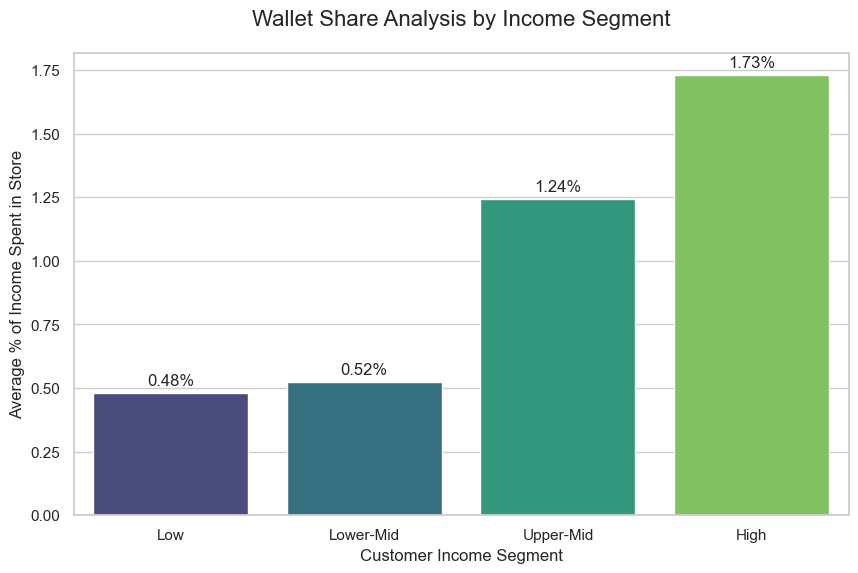

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Setting a professional style for the portfolio chart
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Creating the bar plot for Wallet Share
ax = sns.barplot(x=wallet_insight.index, y=wallet_insight.values, palette="viridis")

plt.title('Wallet Share Analysis by Income Segment', fontsize=16, pad=20)
plt.ylabel('Average % of Income Spent in Store', fontsize=12)
plt.xlabel('Customer Income Segment', fontsize=12)

for p in ax.patches:
    ax.annotate(format(p.get_height(), '.2f') + '%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points')

# Saving the figure
plt.savefig('/Users/fernando/marketing_roi_chart.png', dpi=300, bbox_inches='tight')
plt.show()